# Supplementary Figure S46: training histories

Plot the recorded losses across the stages of model training. Calculate the moving averages used in S46 without repeating training.


## Before you start

Follow the [source installation](../../installation.md), then run these cells in order. The numerical inputs are included with the code. The notebook saves new figures and their calculation tables.

To generate these inputs from fitted models, see the [calculation guide](../../reference/figure_sources/training-histories.md).


## Load the result tables


In [1]:
import os
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results.training_histories import calculate_smoothed_training_history, load_training_history_results, write_training_history_tables

output_dir = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")) / "outputs" / "training_histories_notebook"
output_dir.mkdir(parents=True, exist_ok=True)


In [2]:
results = load_training_history_results()
stage_rows = (
    results.history.groupby(["stage_index", "stage"], sort=False)
    .size()
    .rename("epochs")
    .reset_index()
)
display(stage_rows)
display(results.checkpoint_summary.head(12))


,stage_index,stage,epochs
0,0,Pretrain,100
1,1,Refine,100
2,2,Init_interaction,50
3,3,Train_Score,2001
4,4,Finetune,1000
5,5,Score_Refine,2001


,dataset,stage,first_checkpoint_metric,selected_checkpoint_metric,selected_epoch,configured_epochs,percent_reduction
0,Zebrafish,Pretrain,5.394519,1.288744,74,100,76.110113
1,Zebrafish,Refine,1.512775,0.819021,83,100,45.859727
2,Zebrafish,Init_interaction,0.921314,0.763648,42,50,17.113198
3,Zebrafish,Train_Score,1.031840,0.998628,2001,2001,3.218763
4,Zebrafish,Finetune,0.955431,0.500437,818,1000,47.621824
5,Zebrafish,Score_Refine,1.004910,0.984975,2001,2001,1.983726
6,MOSTA,Pretrain,3.903018,1.595538,94,100,59.120398
7,MOSTA,Refine,1.816029,1.384384,27,100,23.768611
8,MOSTA,Init_interaction,1.514192,1.419337,12,50,6.264408
9,MOSTA,Train_Score,1.021029,1.000848,2001,2001,1.976564


## Calculate centered moving means


In [3]:
smoothed_history = calculate_smoothed_training_history(results)
display(smoothed_history.groupby("stage", sort=False).head(2))


,stage_index,stage,epoch,loss,smoothed_loss
0,0,Pretrain,1,1.097905,1.070802
1,0,Pretrain,2,1.028321,1.062807
100,1,Refine,1,0.910833,0.920480
101,1,Refine,2,1.021966,0.921726
200,2,Init_interaction,1,9.195066,9.184300
201,2,Init_interaction,2,9.750542,9.133559
250,3,Train_Score,1,1.020441,1.012753
251,3,Train_Score,2,1.002391,1.012655
2251,4,Finetune,1,0.890082,0.889697
2252,4,Finetune,2,0.874673,0.889620


## Save the figure and tables


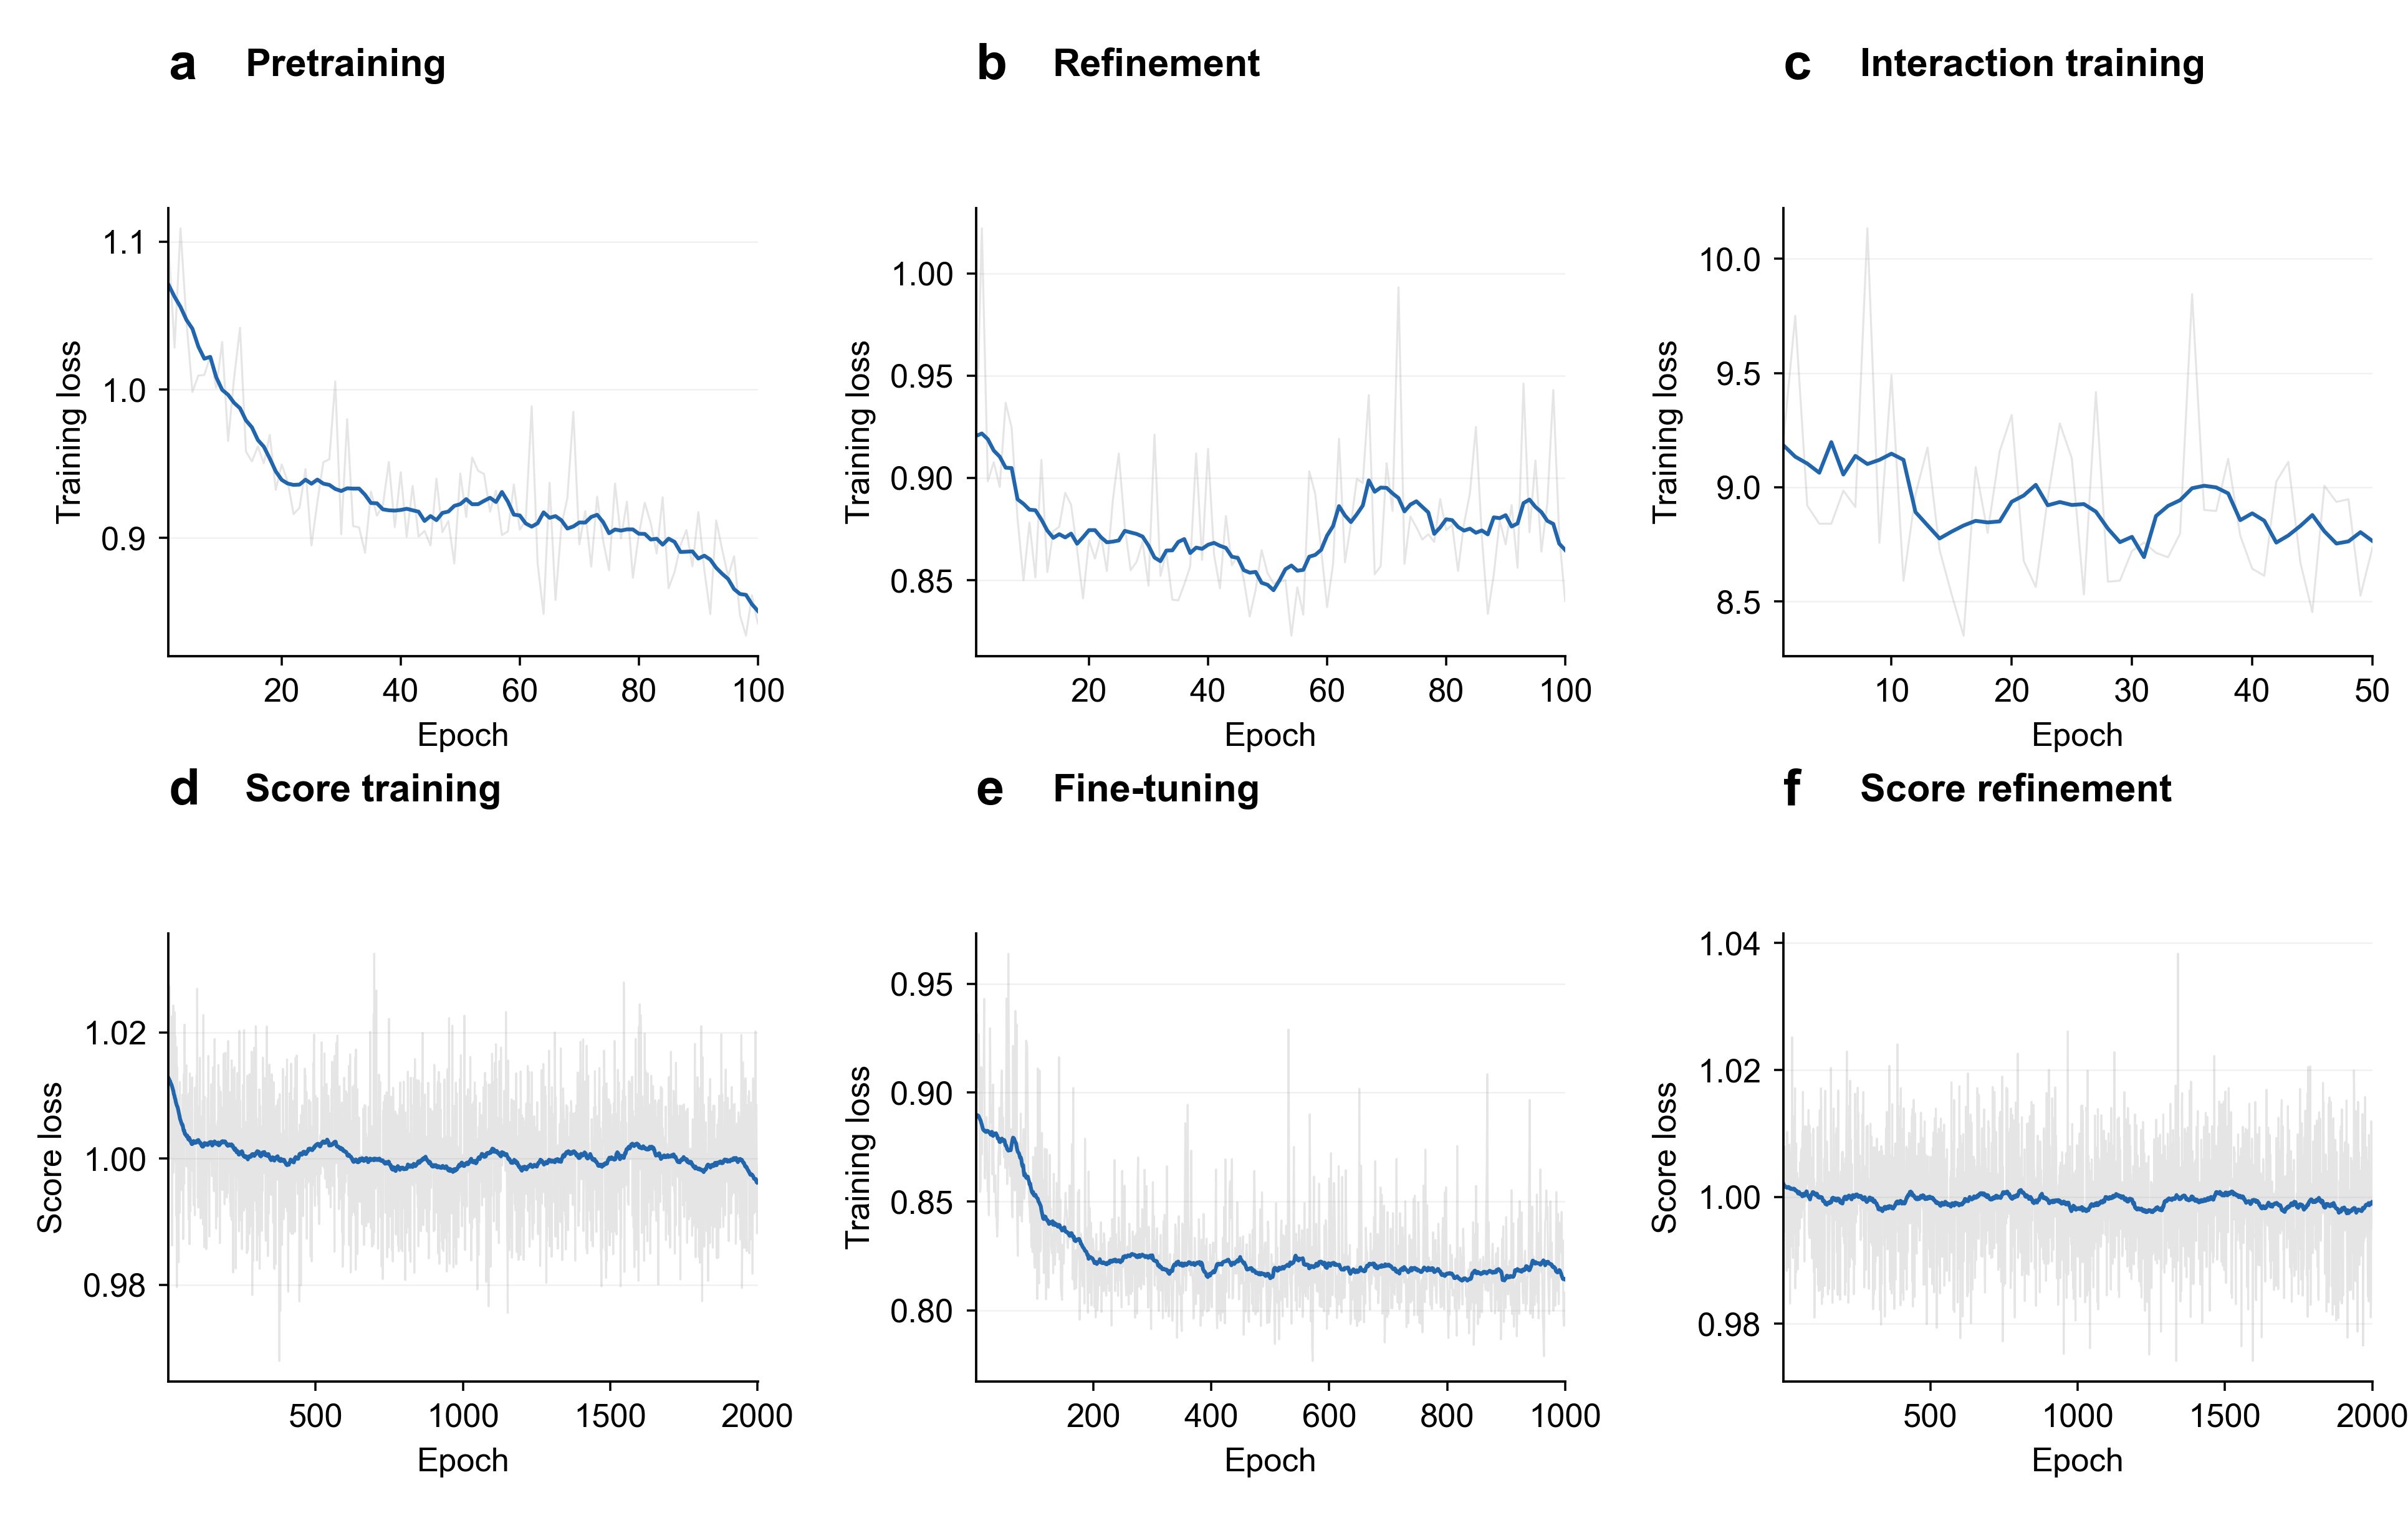

In [4]:
table_paths = write_training_history_tables(results, output_dir)
from reproduction.paper_figures import draw_supplementary
pdf_path, png_path = draw_supplementary([46], output_dir)["s46"]
display(Image(filename=str(png_path), width=900))

## Files


In [5]:
{
    "tables": {name: path.name for name, path in table_paths.items()},
    "pdf": pdf_path.name,
    "png": png_path.name,
}


{'tables': {'smoothed_history': 'arista_training_history_smoothed.csv',
  'checkpoint_summary': 'panel_metrics.csv'},
 'pdf': 'S46.pdf',
 'png': 'S46.png'}